# CHIME/FRB Catalog-1 Waterfall: Replot, Spectrum, and Spectral Index

Data source: CHIME/FRB Collaboration et al. 2021, ApJS, 257, 59 ("Catalog 1"), waterfall data release, DOI `CISTI.CANFAR/21.0007`:

https://www.canfar.net/storage/vault/list/AstroDataCitationDOI/CISTI.CANFAR/21.0007/data/waterfalls/data

Each `*_waterfall.h5` file contains, under group `frb`:

| Key | Description |
|---|---|
| `wfall` | raw dedispersed dynamic spectrum (freq x time) |
| `model_wfall` | best-fit model dynamic spectrum |
| `calibrated_wfall` | flux-calibrated dynamic spectrum (Jy), if available |
| `plot_freq` | frequency axis [MHz] |
| `plot_time` | time axis [ms] |
| `spec` | dynamic spectrum collapsed over time (on-pulse spectrum) |
| `model_spec` | best-fit model spectrum |
| `ts` / `model_ts` | time series (raw / model) |
| `extent` | `[tmin, tmax, fmin, fmax]` for `imshow` |
| attrs | `tns_name`, `dm`, `scatterfit`, `calibration_source_name`, `calibration_observation_date` |

**Requires:** `h5py numpy scipy matplotlib` (`pip install h5py numpy scipy matplotlib`)


In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.signal
import scipy.stats


## 1. Configuration

`H5PATH` points at your local, already-downloaded waterfall file. Adjust `FBIN`/`TBIN` (display-only
binning) and `FIT_FMIN`/`FIT_FMAX` (spectral-index fit band) as needed.


In [2]:
H5PATH = "/fred/oz002/thsu/waterfalls/FRB20181226A_waterfall.h5"
FBIN = 64                # frequency binning factor for the *waterfall display* (fit uses full res)
TBIN = 1                   # time binning factor for the *waterfall display* (fit uses full res)
FIT_FMIN = None               # MHz, restrict spectral-index fit band (or None)
FIT_FMAX = None               # MHz

# NOTE on FBIN/TBIN: the file's native resolution is ~16,384 freq channels
# and sub-ms time samples, so a single pixel has S/N ~ 1 -- displayed at
# native resolution (or only lightly binned) it looks like pure speckle
# noise, not because anything is wrong with the data. The CHIME/FRB catalog
# paper figures are binned much more coarsely purely for display. FBIN=64,
# TBIN=4 below are a reasonable starting point to visually match the paper;
# push them higher for a smoother look, lower to see finer structure.
# `ts`, `spec`, and the spectral-index fit always use the full-resolution
# data -- only the 2D image you see is binned.


## 2. Helper functions

- `boxcar_kernel` / `find_burst`: matched-filter search over boxcar widths to locate the burst peak, width, and S/N.
- `bin_freq_channels`: average adjacent frequency channels together for a cleaner waterfall display.
- `mask_rfi`: flag channels with anomalously high variance or spectrum outliers (same approach as the CHIME/FRB tutorial).
- `fit_spectral_index`: fit `F_nu ~ nu^alpha` to the on-pulse spectrum via a log-log linear regression.


In [3]:
def boxcar_kernel(width):
    width = int(round(width, 0))
    return np.ones(width, dtype="float32") / np.sqrt(width)


def find_burst(ts, min_width=1, max_width=128):
    """Matched-filter search over boxcar widths to find the peak time bin,
    best boxcar width, and S/N of the burst."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))
    snrs = np.empty_like(widths, dtype=float)
    peaks = np.empty_like(widths, dtype=int)
    for i, w in enumerate(widths):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(w), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]
    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]


def bin_freq_channels(data, fbin_factor=4):
    num_chan = data.shape[0]
    if num_chan % fbin_factor != 0:
        raise ValueError("frequency binning factor `fbin_factor` must evenly divide nchan")
    return np.nanmean(
        data.reshape((num_chan // fbin_factor, fbin_factor) + data.shape[1:]), axis=1
    )


def bin_time_samples(data, tbin_factor=4):
    """Average adjacent time samples together (display only). Trims any
    remainder samples that don't fit evenly into tbin_factor."""
    ntime = data.shape[1]
    ntime_trim = (ntime // tbin_factor) * tbin_factor
    data = data[:, :ntime_trim]
    new_shape = data.shape[:1] + (ntime_trim // tbin_factor, tbin_factor)
    return np.nanmean(data.reshape(new_shape), axis=2)


def mask_rfi(wfall, spec, model_wfall=None, var_factor=3):
    """Flag channels with anomalously high variance or spectrum outliers,
    exactly as in the CHIME/FRB tutorial."""
    q1 = np.nanquantile(spec, 0.25)
    q3 = np.nanquantile(spec, 0.75)
    iqr = q3 - q1

    channel_variance = np.nanvar(wfall, axis=1)
    mean_channel_variance = np.nanmean(channel_variance)

    with np.errstate(invalid="ignore"):
        rfi_mask = (
            (channel_variance > var_factor * mean_channel_variance)
            | (spec[::-1] < q1 - 1.5 * iqr)
            | (spec[::-1] > q3 + 1.5 * iqr)
        )
    wfall = wfall.copy()
    wfall[rfi_mask, ...] = np.nan
    if model_wfall is not None:
        model_wfall = model_wfall.copy()
        model_wfall[rfi_mask, ...] = np.nan
    spec = spec.copy()
    spec[rfi_mask[::-1]] = np.nan
    return wfall, spec, model_wfall


def fit_spectral_index(freq_mhz, spec, freq_range=None):
    """
    Fit F_nu ~ nu^alpha to the on-pulse spectrum via ordinary least squares
    in log-log space: log(F) = alpha * log(nu) + const.

    Returns a dict with alpha, alpha_err, intercept, r_value, n_channels_used.
    """
    freq_mhz = np.asarray(freq_mhz, dtype=float)
    spec = np.asarray(spec, dtype=float)

    good = np.isfinite(freq_mhz) & np.isfinite(spec)
    if freq_range is not None:
        good &= (freq_mhz >= freq_range[0]) & (freq_mhz <= freq_range[1])
    # spectrum can be background-subtracted and go negative/zero; log() needs > 0
    good &= spec > 0

    if good.sum() < 5:
        raise ValueError(
            f"Only {good.sum()} usable channels (positive flux, non-NaN) for the fit; "
            "try relaxing freq_range or check RFI masking."
        )

    log_f = np.log10(freq_mhz[good])
    log_s = np.log10(spec[good])

    result = scipy.stats.linregress(log_f, log_s)
    return {
        "alpha": result.slope,
        "alpha_err": result.stderr,
        "intercept": result.intercept,
        "r_value": result.rvalue,
        "n_channels_used": int(good.sum()),
    }


## 3. Load the data and apply RFI masking

In [4]:
import h5py

with h5py.File(H5PATH, "r") as f:
    top_keys = list(f.keys())
    print("Top-level keys:", top_keys)
    print("Root attrs:", dict(f.attrs))

    groups = [k for k in top_keys if isinstance(f[k], h5py.Group)]
    if len(groups) == 1:
        data = f[groups[0]]
        print(f"\nUsing subgroup '{groups[0]}' instead of 'frb'")
    else:
        data = f
        print("\nNo single subgroup found -- using file root directly")

    print("Keys inside data:", list(data.keys()))
    print("Attrs on data:", dict(data.attrs))

Top-level keys: ['frb']
Root attrs: {}

Using subgroup 'frb' instead of 'frb'
Keys inside data: ['calibrated_wfall', 'extent', 'model_spec', 'model_ts', 'model_wfall', 'plot_freq', 'plot_time', 'spec', 'ts', 'wfall']
Attrs on data: {'calibration_observation_date': b'2018-12-02', 'calibration_source_name': b'SNR_G130.7+03.1', 'dm': 349.0106635004, 'scatterfit': False, 'tns_name': b'FRB20181226A'}


In [5]:
with h5py.File(H5PATH, "r") as f:
    data = f["frb"]
    eventname = data.attrs["tns_name"]
    if isinstance(eventname, bytes):
        eventname = eventname.decode()
    dm = float(data.attrs["dm"][()])
    scatterfit = bool(data.attrs["scatterfit"][()])

    wfall = data["wfall"][:]
    model_wfall = data["model_wfall"][:]
    plot_time = data["plot_time"][:]
    plot_freq = data["plot_freq"][:]
    ts = data["ts"][:]
    model_ts = data["model_ts"][:]
    spec = data["spec"][:]
    model_spec = data["model_spec"][:]
    extent = list(data["extent"][:])

print(f"{eventname}: DM = {dm:.2f} pc/cc, scatterfit = {scatterfit}")
print("wfall shape:", wfall.shape)


FRB20181226A: DM = 349.01 pc/cc, scatterfit = False
wfall shape: (16384, 38)


In [6]:
wfall, spec, model_wfall = mask_rfi(wfall, spec, model_wfall)
ts = np.nansum(wfall, axis=0)
model_ts = np.nansum(model_wfall, axis=0)

dt = np.median(np.diff(plot_time))
print(f"dt = {dt:.4f} ms/sample")


dt = 0.9830 ms/sample


/tmp/ipykernel_72684/2623789699.py:48: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall, axis=1)


## 4. Find the burst peak, width, and S/N

In [7]:
peak, width, snr = find_burst(ts)
print(f"Peak: sample {peak}, width = {width} samples ({width*dt:.3f} ms), SNR = {snr:.2f}")


Peak: sample 15, width = 8 samples (7.864 ms), SNR = 469.47


## 5. Measure the spectral index

Fits `F_nu ~ nu^alpha` to the on-pulse spectrum (`spec` vs `plot_freq`) with a log-log OLS regression.
Narrow `FIT_FMIN`/`FIT_FMAX` above if the burst only has signal in part of the band â€” fitting the
full 400-800 MHz range when the burst is narrowband will bias/underconstrain alpha.


In [8]:
freq_range = None
if FIT_FMIN is not None or FIT_FMAX is not None:
    freq_range = (FIT_FMIN if FIT_FMIN is not None else -np.inf,
                  FIT_FMAX if FIT_FMAX is not None else np.inf)

fit = fit_spectral_index(plot_freq, spec, freq_range=freq_range)
print(
    f"Spectral index alpha = {fit['alpha']:.2f} +/- {fit['alpha_err']:.2f} "
    f"(F_nu ~ nu^alpha, R = {fit['r_value']:.3f}, {fit['n_channels_used']} channels used)"
)


Spectral index alpha = -0.16 +/- 0.07 (F_nu ~ nu^alpha, R = -0.029, 6435 channels used)


## 6. Replot the waterfall, time series, and spectrum (with the spectral-index fit overlaid)

Boxcar: peak bin = 15, width = 8 bins (7.864 ms), S/N = 469.47
Using boxcar bins 11-18 for the spectrum (8 bins)
256 / 256 frequency bins retained (0 dead bins removed)
[boxcar bins 11-18, 64-chan binned] alpha = -1.86 +/- 0.52 (R = -0.265, 173 bins used)


/tmp/ipykernel_72684/2623789699.py:26: RuntimeWarning: Mean of empty slice
  return np.nanmean(
/tmp/ipykernel_72684/2623789699.py:38: RuntimeWarning: Mean of empty slice
  return np.nanmean(data.reshape(new_shape), axis=2)


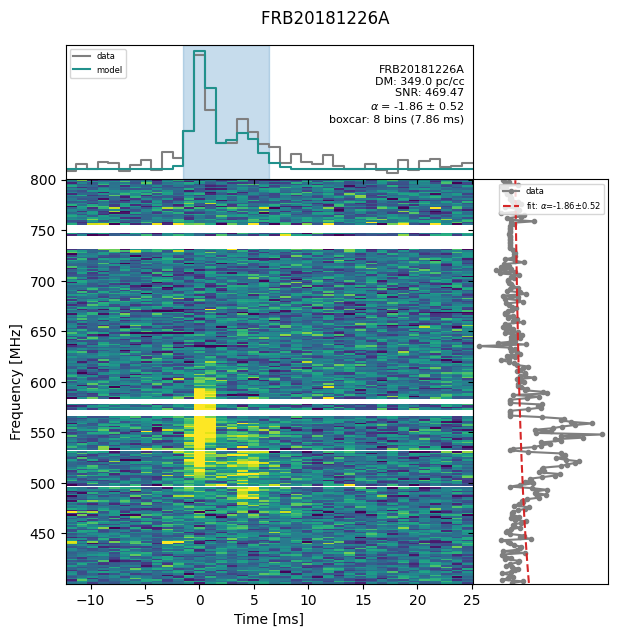

In [20]:
# ---- Waterfall + boxcar-selected, freq-binned spectrum (with fit) ----

# --- Identify the boxcar window from the matched-filter search ---
peak, width, snr = find_burst(ts)   # peak: bin index, width: # bins, snr: matched-filter S/N

# `width` consecutive bins centered on `peak` (mirrors boxcar_kernel + 'same' convolution)
box_lo = int(peak - width // 2)
box_hi = box_lo + width - 1                 # inclusive
box_lo = max(box_lo, 0)
box_hi = min(box_hi, len(ts) - 1)

TIME_BIN_LO = box_lo
TIME_BIN_HI = box_hi
FREQ_BIN_SEL = 64  # frequency binning factor for the spectrum panel

print(f"Boxcar: peak bin = {peak}, width = {width} bins ({width * dt:.3f} ms), "
      f"S/N = {snr:.2f}")
print(f"Using boxcar bins {TIME_BIN_LO}-{TIME_BIN_HI} for the spectrum "
      f"({(TIME_BIN_HI - TIME_BIN_LO + 1)} bins)")

# --- Build the substituted spectrum from the boxcar's time bins ---
time_sel = slice(TIME_BIN_LO, TIME_BIN_HI + 1)

wfall_for_spec = wfall.copy()
dead_chan = np.all(wfall_for_spec == 0, axis=1) | np.all(~np.isfinite(wfall_for_spec), axis=1)
wfall_for_spec[dead_chan, :] = np.nan
wfall_ascending = wfall_for_spec[::-1, :]   # match plot_freq's ascending order

spec_sel_full = np.nansum(wfall_ascending[:, time_sel], axis=1)

def bin_1d(arr, factor):
    n = arr.shape[0]
    n_trim = (n // factor) * factor
    return np.nanmean(arr[:n_trim].reshape(-1, factor), axis=1)

spec_sel_binned = bin_1d(spec_sel_full, FREQ_BIN_SEL)
freq_sel_binned = bin_1d(plot_freq, FREQ_BIN_SEL)

good_bins = np.isfinite(spec_sel_binned)
spec_sel_binned = spec_sel_binned[good_bins]
freq_sel_binned = freq_sel_binned[good_bins]
print(f"{good_bins.sum()} / {len(good_bins)} frequency bins retained "
      f"({(~good_bins).sum()} dead bins removed)")

fit_sel = fit_spectral_index(freq_sel_binned, spec_sel_binned, freq_range=freq_range)
print(
    f"[boxcar bins {TIME_BIN_LO}-{TIME_BIN_HI}, {FREQ_BIN_SEL}-chan binned] "
    f"alpha = {fit_sel['alpha']:.2f} +/- {fit_sel['alpha_err']:.2f} "
    f"(R = {fit_sel['r_value']:.3f}, {fit_sel['n_channels_used']} bins used)"
)

# --- Waterfall display binning ---
wfall_binned = bin_freq_channels(wfall, FBIN)
wfall_binned = bin_time_samples(wfall_binned, TBIN)

fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(
    ncols=2, nrows=2, figure=fig, width_ratios=[3, 1], height_ratios=[1, 3],
    hspace=0.0, wspace=0.0,
)
ax_im = plt.subplot(gs[2])
ax_ts = plt.subplot(gs[0], sharex=ax_im)
ax_spec = plt.subplot(gs[3], sharey=ax_im)

peak_idx = np.argmax(ts)

t = plot_time - plot_time[peak_idx]
t = t - dt / 2.0
t = np.append(t, t[-1] + dt)   # ntime_full + 1 bin edges

ntime_full = wfall.shape[1]
ntime_trim = (ntime_full // TBIN) * TBIN
extent[0] = t[0]
extent[1] = t[ntime_trim]

plot_wfall = np.ma.masked_invalid(wfall_binned)
cmap = plt.cm.viridis.copy()
cmap.set_bad(color="white")
vmin = np.nanpercentile(wfall_binned, 1)
vmax = np.nanpercentile(wfall_binned, 99)

ax_im.imshow(plot_wfall, aspect="auto", interpolation="none", extent=extent,
             vmin=vmin, vmax=vmax, cmap=cmap)
ax_ts.plot(t, np.append(ts, ts[-1]), color="tab:gray", drawstyle="steps-post", label="data")

burst_cmap = plt.cm.viridis
mcolor = burst_cmap(0.25) if scatterfit else burst_cmap(0.5)
ax_ts.plot(t, np.append(model_ts, model_ts[-1]), color=mcolor, drawstyle="steps-post", label="model")

# Shade the boxcar window on the time-series panel (matches the reference image)
box_x_lo = t[TIME_BIN_LO]
box_x_hi = t[TIME_BIN_HI + 1]
ax_ts.axvspan(box_x_lo, box_x_hi, color="tab:blue", alpha=0.25, zorder=0)
ax_ts.legend(fontsize=6, loc="upper left", framealpha=0.8)

# substituted spectrum: boxcar bins, 64-chan binned, dead channels removed
ax_spec.plot(spec_sel_binned, freq_sel_binned, color="tab:gray", marker=".",
             label=f"data")

freq_fit = np.linspace(np.nanmin(freq_sel_binned), np.nanmax(freq_sel_binned), 200)
spec_fit = 10 ** fit_sel["intercept"] * freq_fit ** fit_sel["alpha"]
ax_spec.plot(spec_fit, freq_fit, color="tab:red", lw=1.5, ls="--",
             label=fr"fit: $\alpha$={fit_sel['alpha']:.2f}$\pm${fit_sel['alpha_err']:.2f}")
ax_spec.legend(fontsize=6, loc="upper right")

plt.setp(ax_ts.get_xticklabels(), visible=False)
ax_ts.set_yticks([])
ax_ts.set_xlim(extent[0], extent[1])
plt.setp(ax_spec.get_yticklabels(), visible=False)
ax_spec.set_xticks([])
ax_spec.set_ylim(extent[2], extent[3])

ax_im.set_xlabel("Time [ms]")
ax_im.set_ylabel("Frequency [MHz]")
ax_ts.text(
    0.98, 0.85,
    f"{eventname}\nDM: {dm:.1f} pc/cc\nSNR: {snr:.2f}\n"
    fr"$\alpha$ = {fit_sel['alpha']:.2f} $\pm$ {fit_sel['alpha_err']:.2f}"
    f"\nboxcar: {width} bins ({width * dt:.2f} ms)",
    transform=ax_ts.transAxes, ha="right", va="top", fontsize=8,
)

fig.suptitle(f"{eventname} ", y=0.93)
plt.show()



In [11]:
print (wfall.shape)

(16384, 38)
